# 101.3. Data services overview

<div style="max-width:300px; float: left; margin-right: 1em">

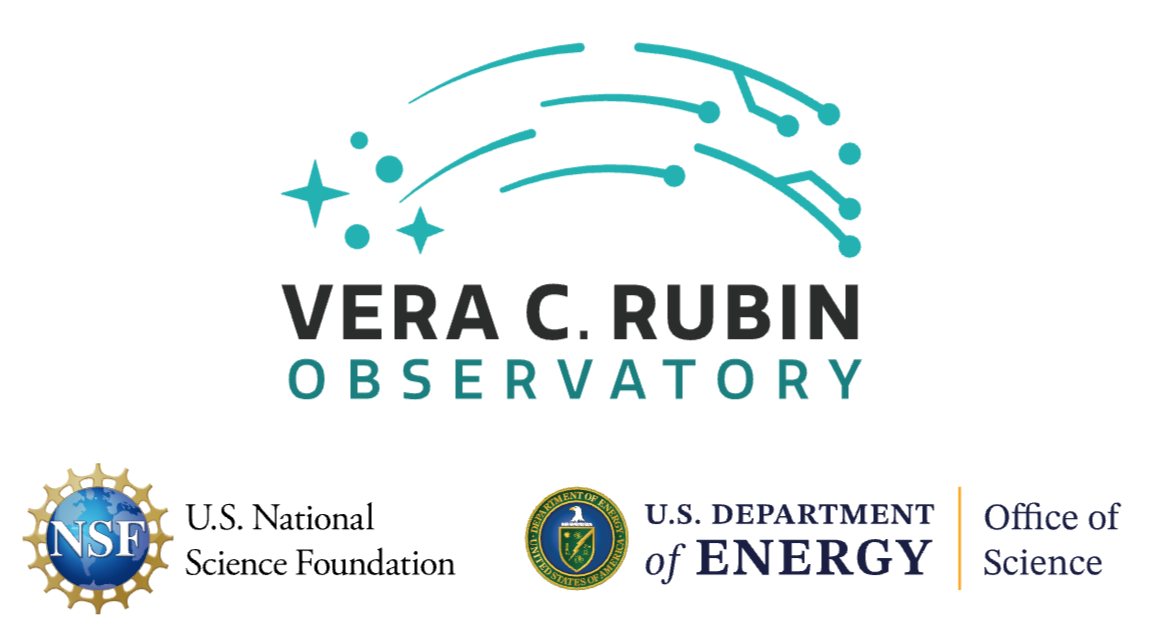

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 2](https://dp2.lsst.io/)\
Container Size: Large\
LSST Science Pipelines version: r30.0.9\
Last verified to run: 2026-07-20\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** To get a general understanding of the data access services.

**LSST data products:** `Object` table, `deep_coadd` image

**Packages:** `lsst.daf.butler`, `lsst.rsp.RSPDiscovery`, `lsst.images`

**Credit:**
Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This tutorial provides an overview of simple catalog and image queries in each of the RSP's data access services: the Butler ([middleware documentation](https://pipelines.lsst.io/middleware/index.html)), TAP ([Table Access Protocol](http://www.ivoa.net/documents/TAP)), SIA ([Simple Image Access](https://www.ivoa.net/documents/SIA/)), and the cutouts service.
The general use-cases for each service are described, and pointers to more in-depth tutorials for each are provided.

### 1.1. Import packages

Import the `numpy` and `matplotlib.pyplot` packages, along with standard python package `io`.

Import the following packages for the LSST data access services.

* Butler: `lsst.daf.butler`
* TAP and SIA queries:
  * `lsst.rsp.RSPDiscovery`
  * `lsst.images.serialization.read_archive`
* Image display: `lsst.afw.display`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import io
from lsst.daf.butler import Butler
from lsst.rsp import RSPDiscovery
from lsst.images.serialization import read_archive
import lsst.afw.display as afw_display

### 1.2. Define parameters

Instantiate `RSPDiscovery` with the DP2 release.

In [ ]:
discovery = RSPDiscovery("dp2")

Instantiate the TAP service.

In [ ]:
tap_service = discovery.get_tap_client()

Instantiate the Butler.

In [ ]:
butler = Butler("dp2", collections="dp2")

Instantiate the SIA service.

In [ ]:
sia_service = discovery.get_sia_client()

Open the image display tab, Firefly, and ready frame 1 for display.

In [ ]:
afw_display.setDefaultBackend("firefly")
display = afw_display.Display(frame=1)

Define the target coordinates in RA, Dec, and a radius (all in degrees) to use in example queries.
These coordinates are for the center of the Extended Chandra Deep Field South (ECDFS).

In [ ]:
targ_ra = 53.2
targ_dec = -28.1
targ_rad = 0.5

## 2. Catalog data

Catalog data is accessible via the TAP and Butler services.

**Related tutorials for catalogs:**
* The 200-level series "Catalogs" contains details about the format and contents of the catalogs.

### 2.1. TAP

TAP is the recommended service for catalog data access.
The TAP service takes queries in ADQL ([Astronomy Data Query Language](http://www.ivoa.net/documents/latest/ADQL.html)).

TAP catalog queries should:
* have spatial constraints
* specify the columns to return
* be run asynchronously

**Related tutorials for catalogs via TAP:**
* The 100-level series "Catalog access" provides guidance on efficient queries and advanced TAP query options such as schema browsing, polygon spatial queries, table joins, derived values, sorting, grouping, user-table upload, cross-match, and so on.
* The 300-level series "Interactive data visualization" demonstrates how to make more sophisticated, interactive plots that can accommodate millions of data points.

**Execute a TAP query.** Create an ADQL query that will select (return values in) the following columns of the `Object` table: the Object identifier, right ascension and declination, $g$- and $r$-band `cModelMag`.
Include spatial constraints as a cone search that will only return objects within the specified radius of the target RA and Dec (in degrees), and include column constraints that magnitudes must be between 17 and 23 mag.
Run the query as an asynchronous job, then fetch the results as an Astropy table with `.to_table()`.
This query returns a very modest number of rows.

In [ ]:
query = """SELECT objectId, coord_ra, coord_dec, g_cModelMag AS gmag, r_cModelMag AS rmag
        FROM dp2.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', {}, {}, {})) = 1
        AND g_cModelMag < 23 AND r_cModelMag < 23 AND g_cModelMag > 17 AND r_cModelMag > 17
        """.format(targ_ra, targ_dec, targ_rad)
print(query)
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
tbl = job.fetch_result().to_table()
print('Number of rows returned: ', len(tbl))

Option to view the results table.

In [ ]:
# tbl

**Visualize the results data** with a color-magnitude diagram.

In [ ]:
fig = plt.figure(figsize=(4, 3))
plt.plot(tbl['gmag']-tbl['rmag'], tbl['rmag'], 'o', ms=3, mew=0, alpha=0.2, color='black')
plt.xlabel('g-r')
plt.ylabel('r')
plt.ylim(23, 17)
plt.show()

> **Figure 1:** A color-magnitude diagram for the TAP results.

Delete the job, query, and results.

In [ ]:
job.delete()
del query, tbl

### 2.2. Butler

The Butler is the LSST Science Pipelines interface for managing, reading, and writing datasets. As the interface between the pipelines and the data, it is often referred to as "middleware".

The TAP service is recommended for catalog access because with the Butler, tables are returned for an entire visit or tract, and queries with coordinate or column constraints are not possible. Butler catalog access is most useful when all of the sources in a given visit or tract are desired.

Butler catalog queries should:
* desire all sources/objects in a given visit/tract
* specify the columns to return

**Related tutorials for catalogs with the Butler:**
* The 100-level series "Butler data access" contains more information on dataset types, use of the `dataId`, spatial and temporal queries, bind parameters, sorting, and applying limits.

**Create a butler query** to find all object table tracts that overlap the target coordinates.
In this example there is only one overlapping tract, but note that tracts do overlap at their edges and corners, so it could be up to four.
Define the columns to return, and get the results from the Butler.

In [ ]:
query = "tract.region OVERLAPS POINT(:ra, :dec)"
refs = butler.query_datasets("object", where=query, bind={"ra": targ_ra, "dec": targ_dec})
print('Number of overlapping object tract tables: ', len(refs))
column_names = ['objectId', 'coord_ra', 'coord_dec', 'g_cModelFlux', 'r_cModelFlux']
tbl = butler.get(refs[0], parameters={'columns': column_names})
print('Number of objects retrieved for tract: ', len(tbl))

The Butler stores the data in fluxes only (the units are nJy). Convert positive fluxes to AB magnitudes. (All fluxes in the Object table are forced photometry, and can be negative for objects with no discernible flux due to random fluctuations in the sky-subtracted background of the image.)

In [ ]:
tbl['gmag'] = np.zeros(len(tbl), dtype='float') + 99
tbl['rmag'] = np.zeros(len(tbl), dtype='float') + 99
gx = np.where(tbl['g_cModelFlux'] > 0.0)[0]
tbl['gmag'][gx] = -2.5 * np.log10(tbl['g_cModelFlux'][gx]) + 31.4
rx = np.where(tbl['r_cModelFlux'] > 0.0)[0]
tbl['rmag'][rx] = -2.5 * np.log10(tbl['r_cModelFlux'][rx]) + 31.4
del gx, rx

**Visualize the results data.** Create the same plots as in Figure 1 for a random sub-set of 10000 objects, and only where the forced photometry magnitude is $<30$ mag.

In [ ]:
fig = plt.figure(figsize=(4, 3))
tx = np.where((tbl['gmag'] < 30) & (tbl['rmag'] < 30))[0]
rx = np.random.choice(tx, size=10000, replace=False)
plt.plot(tbl['gmag'][rx]-tbl['rmag'][rx], tbl['rmag'][rx],
         'o', ms=3, mew=0, alpha=0.2, color='black')
plt.xlabel('g-r')
plt.ylabel('r')
plt.ylim(30, 16)
plt.show()
del tx, rx

> **Figure 2:** A color-magnitude diagram for the Butler results.

Delete the query and the results.

In [ ]:
del query, refs, column_names, tbl

## 3. Image data

Image data is accessible via the Butler, SIA, TAP, and cutouts services.

**Related tutorials for images:**
* The 100-level series "Image access and display" contains detailed demonstrations for each of the RSP's image query and visualization services, and various types of cutouts.
* The 200-level series "Images" contains more information about image formats and metadata, such as the mask plane, WCS, PSF, and so on.

### 3.1. Butler

The Butler is the recommended tool for image access.

Butler catalog queries should:
* include a spatial constraint (e.g., overlaps point)

**Related tutorials for images via the Butler:**
* The 100-level series "Butler data access" contains more information on dataset types, use of the `dataId`, spatial and temporal queries, bind parameters, sorting, and applying limits.

**Create a Butler query** for $r$-band deep coadd patch images that overlap the target coordinates, retrieve the first in the `refs` list from the Butler.

In [ ]:
query = "band.name = 'r' AND patch.region OVERLAPS POINT(:ra, :dec)"
refs = butler.query_datasets("deep_coadd", where=query, bind={"ra": targ_ra, "dec": targ_dec})
print('Number of overlapping deep coadd patches: ', len(refs))
deep_coadd = butler.get(refs[0])

**Display the deep coadd image in Firefly** and set the mask to be fully transparent so that only the pixel data is shown.

In [ ]:
display.image(deep_coadd)
display.setMaskTransparency(100)

The image in the Firefly viewer should look like the following.

<div style="max-width:300px">

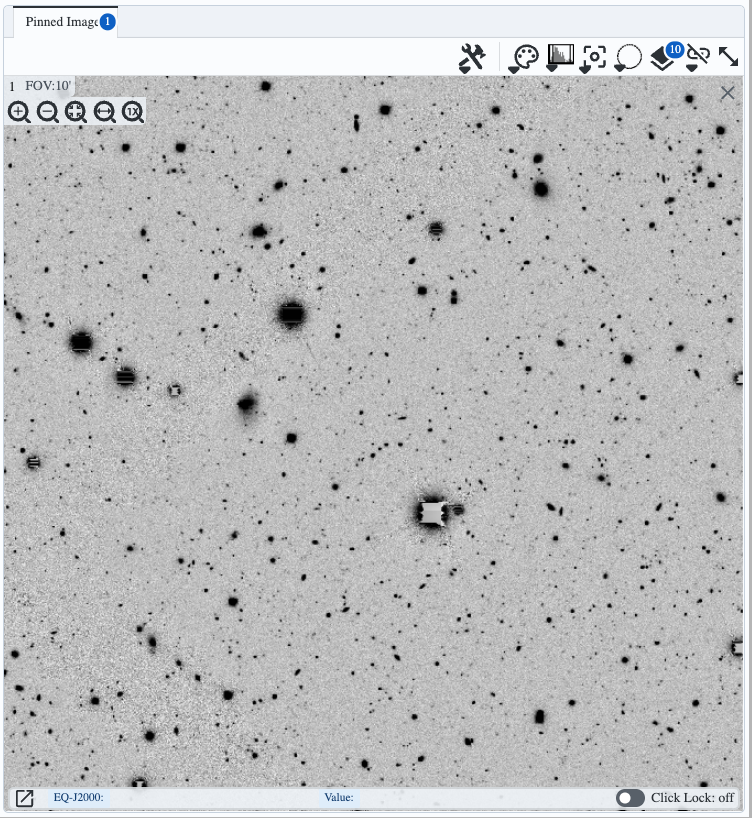

</div>

> **Figure 3:** The $r$-band deep coadd image displayed in the Firefly window.
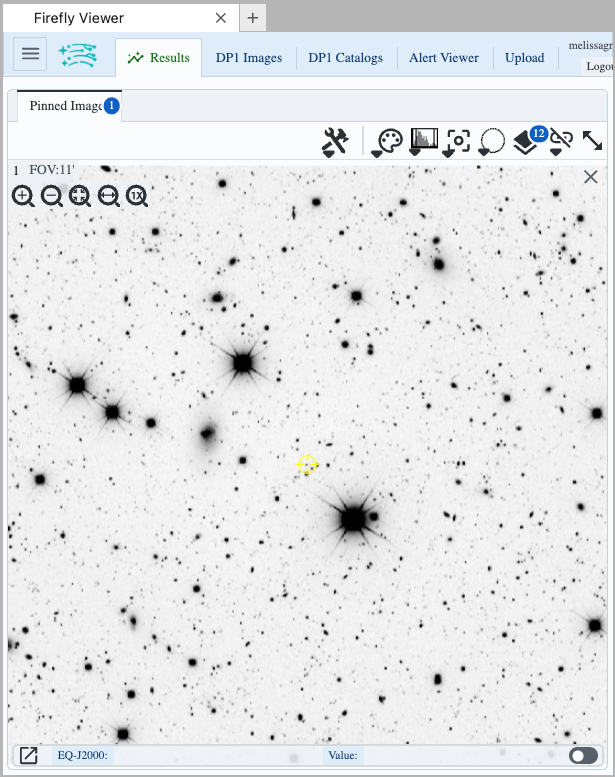
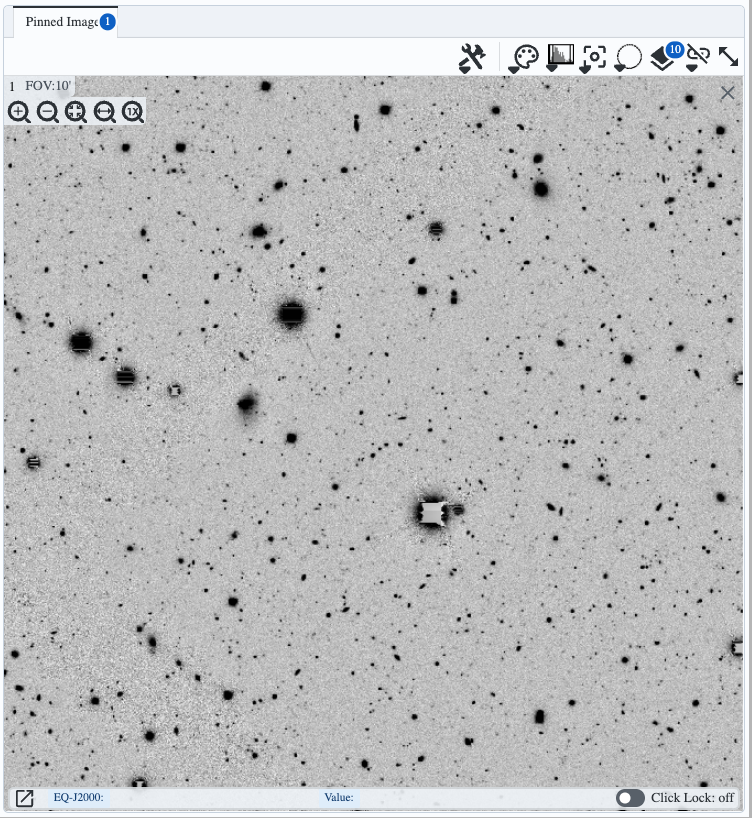

Delete the query and the results.

In [ ]:
del query, refs, deep_coadd

### 3.2. SIA

SIA (Simple Image Access) is a protocol of the International Virtual Observatory Alliance (IVOA) that provides a standardized model for image metadata (spatial, temporal, and spectral coverage).

SIA queries should specify:
* spatial constraints (coordinate or region overlap)
* a calibration level and an image subtype

Calibration levels and data product subtypes names are:
 - 1 : `raw`
 - 2 : `visit_image`
 - 3 : `deep_coadd`, `template_coadd`, `difference_image`

Additional constraints on band, time, and date are also possible.

**Related tutorials for images via SIA:**
* The 100-level series "Image access and display" contains a SIA tutorial, including how to put constraints on the filter.

**Create a SIA query** for deep coadd images that overlap a 1" (0.05 deg) circle centered on the target RA, Dec defined above. This area is so small that it is essentially an "overlaps point" query, but larger areas will also work with SIA.

In [ ]:
circle = (targ_ra, targ_dec, 0.0003)
results = sia_service.search(pos=circle, calib_level=3, dpsubtype='lsst.deep_coadd')
print('Number of matching images: ', len(results.to_table()))

Option to display the `results` as a table of image metadata.

In [ ]:
# results.to_table()

Select the $r$-band image from the table, and get the `image_url` for the $r$-band image.

In [ ]:
tx = np.where(results['lsst_band'] == 'r')[0]
result = results.getrecord(tx[0])
del tx
dl_result = discovery.get_datalink_results(result)
image_url = dl_result.getrecord(0).get('access_url')

Use the `image_url` to retrieve the deep coadd image. This cell produces no output unless an error occurs.

In [ ]:
deep_coadd_2 = read_archive(image_url)

**Display the image** in a second frame in the Firefly window. It will be the same as the image displayed in Section 3.1 above.

In [ ]:
display = afw_display.Display(frame=2)
display.image(deep_coadd_2)
display.setMaskTransparency(100)

Delete the query and the results.

In [ ]:
del circle, results, result, dl_result, image_url, deep_coadd_2

### 3.3. TAP

The ObsCore table contains image metadata and is accessible via the TAP service. It's the same image metadata table accessed by SIA, using the same TAP service as demonstrated for catalogs in Section 2.1.

ObsCore TAP queries should specify:
* spatial constraints (coordinate or region overlap)
* an image subtype

The image subtypes are `raw`, `visit_image`, `deep_coadd`, `template_coadd`, `difference_image`. Additional constraints on band, time, and date are also possible.

**Related tutorials for images via TAP:**
* The 100-level series "Image access and display" contains an ObsCore TAP tutorial, demonstrating options for spatial and temporal query constraints.

**Create an ObsCore TAP query** for the $r$-band deep coadd image that contains the target RA, Dec. Execute the query and return the table of results, which will have just 1 row.

> **Notice:** Both DP1 and DP2 image metadata are stored in the `ObsCore` table, so the `obs_collection` must be specified as `LSST.DP2` or else matching DP1 images will be returned.

In [ ]:
query = """SELECT * FROM ivoa.ObsCore
        WHERE CONTAINS(POINT('ICRS', {}, {}), s_region) = 1
        AND obs_collection = 'LSST.DP2' AND dataproduct_subtype = 'lsst.deep_coadd'
        AND lsst_band = 'r'""".format(targ_ra, targ_dec)
print(query)
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
results = job.fetch_result()
print('Number of matching images: ', len(results.to_table()))

Option to display the results as a table.

In [ ]:
# results.to_table()

Retrieve the image using the same method as retrieving an image identified via the SIA service.

In [ ]:
result = results.getrecord(0)
dl_result = discovery.get_datalink_results(result)
image_url = dl_result.getrecord(0).get('access_url')
deep_coadd_3 = read_archive(image_url)

In [ ]:
display = afw_display.Display(frame=3)
display.image(deep_coadd_3)
display.setMaskTransparency(100)

Delete the job, query, and results.

In [ ]:
job.delete()
del query, results, result, dl_result, image_url, deep_coadd_3

### 3.4. Cutouts

The cutout service enables *server-side cutouts*: for a given image, request that only the desired pixels are returned.

**Related tutorials for cutout images:**
* The 100-level series "Image access and display" provides more extensive cutouts demos, including different ways to define the regions and how to reduce the amount of metadata transferred (e.g., the mask and variance pixel planes).

Define the coordinates, RA, Dec, of an interesting-looking object for which to create a cutout. Set the cutout size to 20 arcsec.

In [ ]:
cutout_ra = 53.2178468
cutout_dec = -28.0939902
cutout_size = 20./3600.

The SIA or TAP services can be used to identify the image from which the cutout is to be made. This demo uses the SIA service identify the $r$-band image that overlaps the desired cutout region, and get its `image_id`.

In [ ]:
circle = (cutout_ra, cutout_dec, cutout_size)
results = sia_service.search(pos=circle, calib_level=3, dpsubtype='lsst.deep_coadd')
tx = np.where(results['lsst_band'] == 'r')[0]
result = results.getrecord(tx[0])
del tx
dl_result = discovery.get_datalink_results(result)
image_id = dl_result.getrecord(0).id

Use the `discovery` service to establish a `session` and get the URL for the cutout service.

In [ ]:
session = discovery.get_session()
cutouts_url = discovery.get_service_url("cutout", version="soda-sync-1.0")

Pass the desired cutout specifications and the service URL to the `session` and read the contents of the response.

In [ ]:
params = {"id": image_id, "cutoutdetail": "Exposure",
          "circle": f"{cutout_ra} {cutout_dec} {cutout_size}"}
response = session.get(cutouts_url, params=params, timeout=60)
response.raise_for_status()
cutout = read_archive(io.BytesIO(response.content))

Display the cutout in Firefly frame 4.

In [ ]:
display = afw_display.Display(frame=4)
display.image(cutout)
display.setMaskTransparency(100)

<div style="max-width:300px">

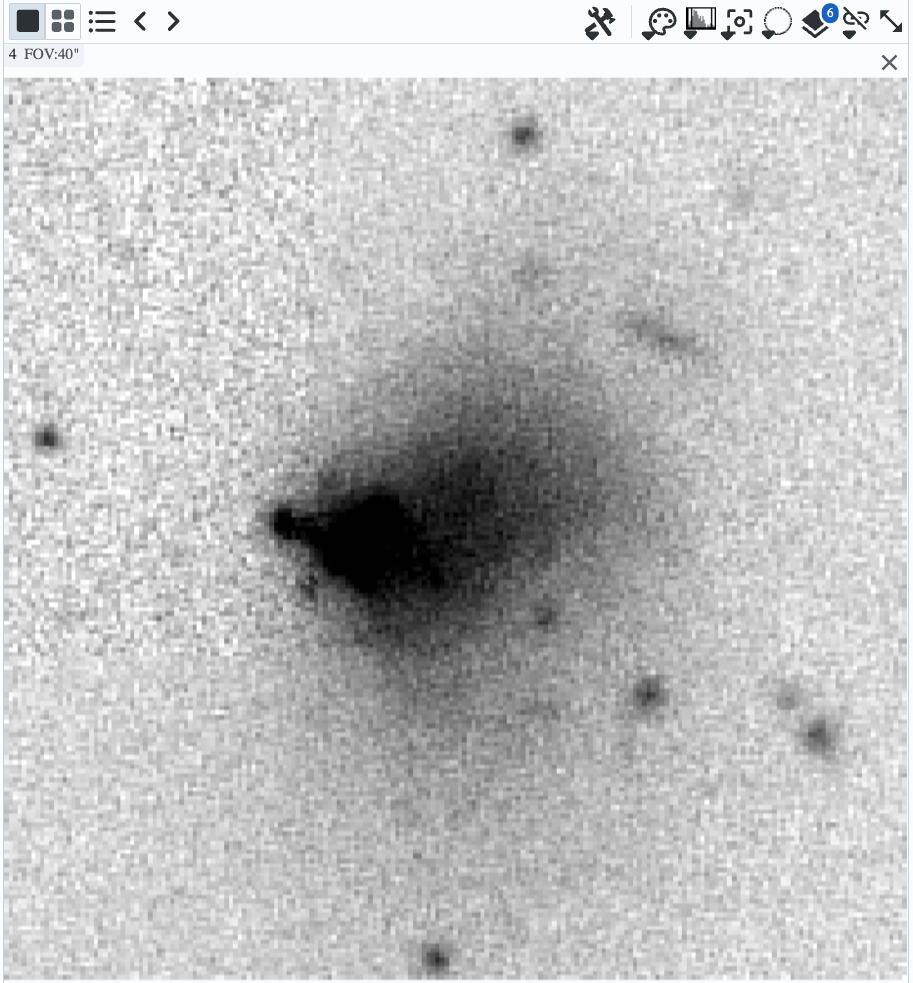

</div>

> **Figure 4:** The cutout as displayed in the Firefly tab.

Clean up.

In [ ]:
del circle, results, result, dl_result, image_id
del session, cutouts_url, params, response, cutout